# Fashion MNIST Clothing Classification: Fundamentals of Neural Networks

This notebook introduces deep learning fundamentals using the **Fashion MNIST** dataset, with a focus on building intuition through clear baselines and simple experiments.

## Project goals

- Build a feedforward neural network (MLP) for clothing item classification and understand the main training workflow (train/validate/test).
- Compare the neural network against two classical baselines:
  - Logistic Regression
  - Decision Tree
- Learn how to evaluate models fairly using the same data splits and consistent metrics, and why baselines matter before adding complexity.

## What this notebook will include

- Data loading and preprocessing for Fashion MNIST (normalization, train/validation/test split).
- Baseline 1: Logistic Regression (fast, strong reference point).
- Baseline 2: Decision Tree (interpretable, non-linear baseline).
- Model 3: Feedforward neural network (dense layers) with a simple, reproducible setup.
- Side-by-side comparison:
  - Accuracy and confusion matrix
  - Training time and practical tradeoffs
  - Common errors and what they suggest to improve next


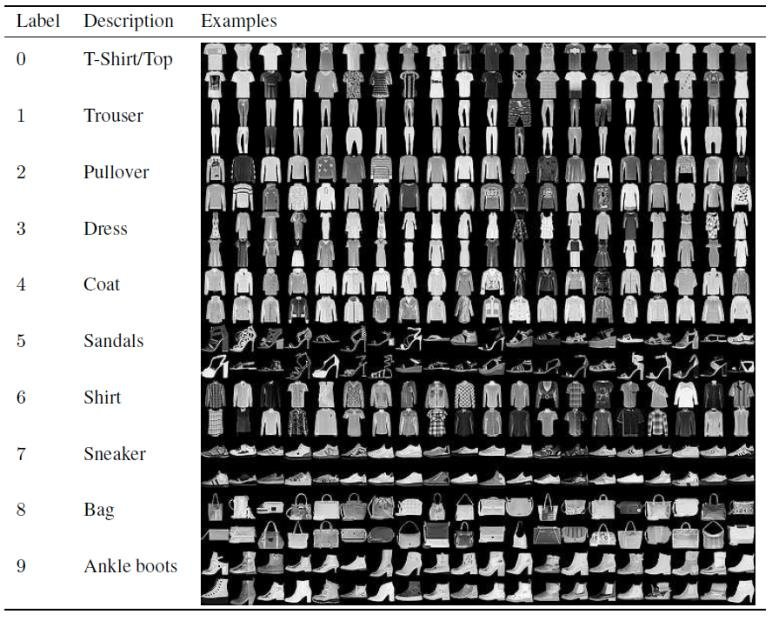

## Project phases

### 1) Setup
- Import libraries and set seeds for reproducibility.
- Define a common evaluation plan (same splits, same metrics for all models).

### 2) Data preparation
- Load MNIST.
- Normalize inputs and create train/validation/test splits.

### 3) Baseline models
- Train Logistic Regression as a fast reference point.
- Train a Decision Tree as an interpretable non-linear baseline.

### 4) Feedforward neural network
- Build a small MLP (dense layers).
- Train with a clear training loop and validation monitoring.

### 5) Evaluation and comparison
- Compare all models on the test set using the same metrics.
- Add a confusion matrix and inspect the most common mistakes.

### 6) Short conclusions
- Summarize tradeoffs (accuracy, training time, simplicity).
- List 2–3 concrete next improvements (regularization, tuning, better preprocessing).


# Setup + Fashion-MNIST Context

## What Fashion-MNIST is
Fashion-MNIST is a small dataset of grayscale images of clothing items (such as shirts, trousers, shoes, and bags), used for classification tasks.  
It was designed as a more challenging replacement for the classic MNIST digit dataset, offering a realistic benchmark for computer vision models while still being simple to load, quick to train, and easy to compare across different approaches before moving on to more complex vision problems.

## What we do in this phase
- Import the core libraries (NumPy, scikit-learn, and a deep learning framework for the MLP).  
- Set random seeds so results are reproducible across runs.  
- Define a consistent evaluation plan (same train/validation/test split and the same metrics for every model), because disciplined baselines and honest measurement matter more than “fancy” modeling.


In [1]:
# Core
import numpy as np
import random

# Visualization
import matplotlib.pyplot as plt

# Classical ML baselines
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Deep learning (for Fashion-MNIST + feedforward network later)
import tensorflow as tf

# Reproducibility: set Python + NumPy + TensorFlow seeds in one call
SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)


## Load Fashion-MNIST + Quick Inspection

Load the Fashion-MNIST dataset and do a fast sanity check before training anything.  
The goal is to confirm the data shapes and visually verify that the labels match the clothing item images.

- Load `(x_train, y_train)` and `(x_test, y_test)` from `tf.keras.datasets.fashion_mnist`.  
- Print the shapes of images and labels to ensure consistency.  
- Display a **2×5** grid of random training images with their labels (e.g., "T-shirt", "Sneaker", "Bag") to visually confirm that the labels correspond to the images.  


In [2]:
# Load Fashion-MNIST (returns 2 tuples: train and test)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()  # ready-to-use

# Check shapes (sanity check)
print("x_train shape:", x_train.shape, "| y_train shape:", y_train.shape)
print("x_test  shape:", x_test.shape,  "| y_test  shape:", y_test.shape)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28) | y_train shape: (60000,)
x_test  shape: (10000, 28, 28) | y_test  shape: (10000,)


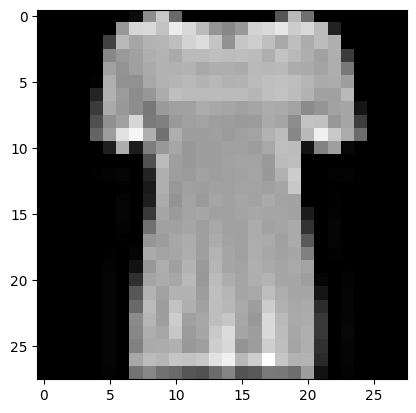

In [3]:
import matplotlib.pyplot as plt
plt.imshow(x_train[10], cmap="gray")

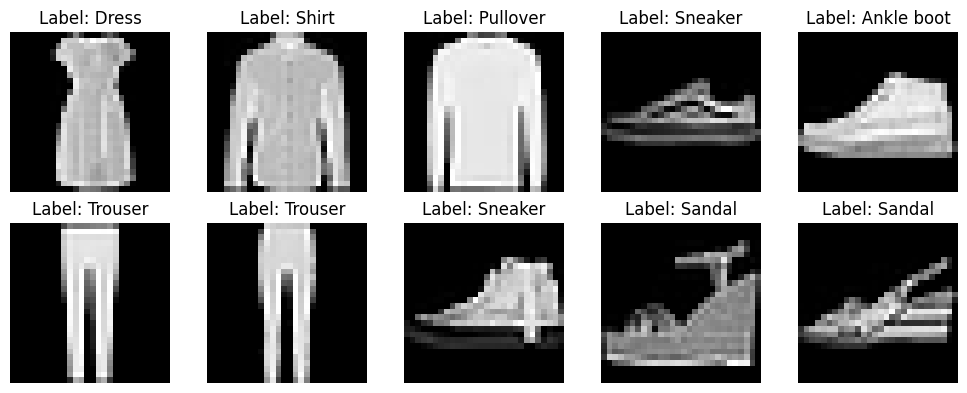

In [4]:
# Show a 2×5 grid of random Fashion-MNIST training images
rng = np.random.default_rng(42)
idx = rng.choice(len(x_train), size=10, replace=False)  # random indices

# Fashion-MNIST label names
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.ravel()

for ax, i in zip(axes, idx):
    ax.imshow(x_train[i], cmap="gray")
    ax.set_title(f"Label: {class_names[y_train[i]]}")
    ax.axis("off")  # hide axes per subplot

plt.tight_layout()
plt.show()


# Data Preparation

## Normalization
Normalize the Fashion-MNIST pixel values so all inputs are on a consistent scale (0–1).  
This helps training behave more predictably and makes model comparisons fair.  
Since Fashion-MNIST images are grayscale with pixel values in the range [0, 255], we divide by 255.0.

## Splits
We create three splits to ensure disciplined evaluation:

- **Train**: used to fit model parameters.  
- **Validation**: used to tune choices (e.g., model size, learning rate) without touching the test set.  
- **Test**: used once at the end for an honest final result.  


In [5]:
from sklearn.model_selection import train_test_split

# --- Normalize ---
# Fashion MNIST pixels are in [0, 255]. Convert to float32 and scale to [0, 1].
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# --- Create train/validation split ---
# Keep the original x_test/y_test as the final test set.
# Split x_train into train and validation, preserving label proportions.
X_train, X_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", x_test.shape, y_test.shape)

Train: (48000, 28, 28) (48000,)
Val:   (12000, 28, 28) (12000,)
Test:  (10000, 28, 28) (10000,)


## Baseline models

Before building a neural network, train simple baseline models to establish a clear reference point and ensure the evaluation is honest. Baselines help verify that the data pipeline is correct and prevent unnecessary complexity when simpler models already perform well.

- **Logistic Regression:** Train this first. It is fast, effective for many classification tasks, and provides a solid minimum performance benchmark to beat.
- **Decision Tree:** Use this as an interpretable non-linear baseline. It enables comparison between a simple rule-based model and more complex learning approaches.

Use the same train/validation split and the same evaluation metrics for both baseline models.


In [6]:
# sklearn models expect 2D inputs: (n_samples, n_features)
# Flatten 28x28 images to 784-length vectors
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat   = X_val.reshape(X_val.shape[0], -1)
X_test_flat  = x_test.reshape(x_test.shape[0], -1)

# ---- Baseline 1: Logistic Regression ----
log_reg = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=300,
    n_jobs=-1
)  # multinomial supported by lbfgs
log_reg.fit(X_train_flat, y_train)
val_pred_lr = log_reg.predict(X_val_flat)
print("LogReg validation accuracy:", accuracy_score(y_val, val_pred_lr))
print("LogReg confusion matrix (val):\n", confusion_matrix(y_val, val_pred_lr))

# ---- Baseline 2: Decision Tree ----
tree = DecisionTreeClassifier(
    random_state=42
)  # basic classifier API: fit/predict
tree.fit(X_train_flat, y_train)
val_pred_tree = tree.predict(X_val_flat)
print("Decision Tree validation accuracy:", accuracy_score(y_val, val_pred_tree))
print("Decision Tree confusion matrix (val):\n", confusion_matrix(y_val, val_pred_tree))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogReg validation accuracy: 0.8604166666666667
LogReg confusion matrix (val):
 [[1004    3   21   43    5    2  104    0   18    0]
 [   3 1156    4   29    3    1    4    0    0    0]
 [  24    2  905   19  131    0  110    0    9    0]
 [  59   17   18 1026   44    0   32    0    4    0]
 [   5    0  107   43  935    0  100    0    9    1]
 [   1    0    0    1    0 1145    2   30    2   19]
 [ 171    5  117   33  113    0  745    0   16    0]
 [   0    0    0    0    0   41    0 1123    1   35]
 [   1    0    6   12    2    7   24    6 1140    2]
 [   0    0    0    0    0   17    0   36    1 1146]]
Decision Tree validation accuracy: 0.7971666666666667
Decision Tree confusion matrix (val):
 [[ 904    9   27   38   16    3  191    0   11    1]
 [   8 1145    4   27    5    1    8    0    2    0]
 [  31    9  819   24  158    1  138    0   17    3]
 [  64   43   25  934   63    1   51    0   18    1]
 [   7    4  192   62  786    1  136    0   11    1]
 [   3    3    0    4    2 1078 

# Comparing Baseline Confusion Matrices

To compare the baselines visually, we plot their confusion matrices side by side using Matplotlib subplots and scikit-learn's ConfusionMatrixDisplay.

- We create a 1×2 figure using `plt.subplots(1, 2, ...)`.
- We plot the Logistic Regression confusion matrix on the left axis.
- We plot the Decision Tree confusion matrix on the right axis.
- We use consistent labels and a shared color style so the two plots are easy to compare.
- Fashion MNIST has 10 clothing categories (0–9), so each confusion matrix will be 10×10.


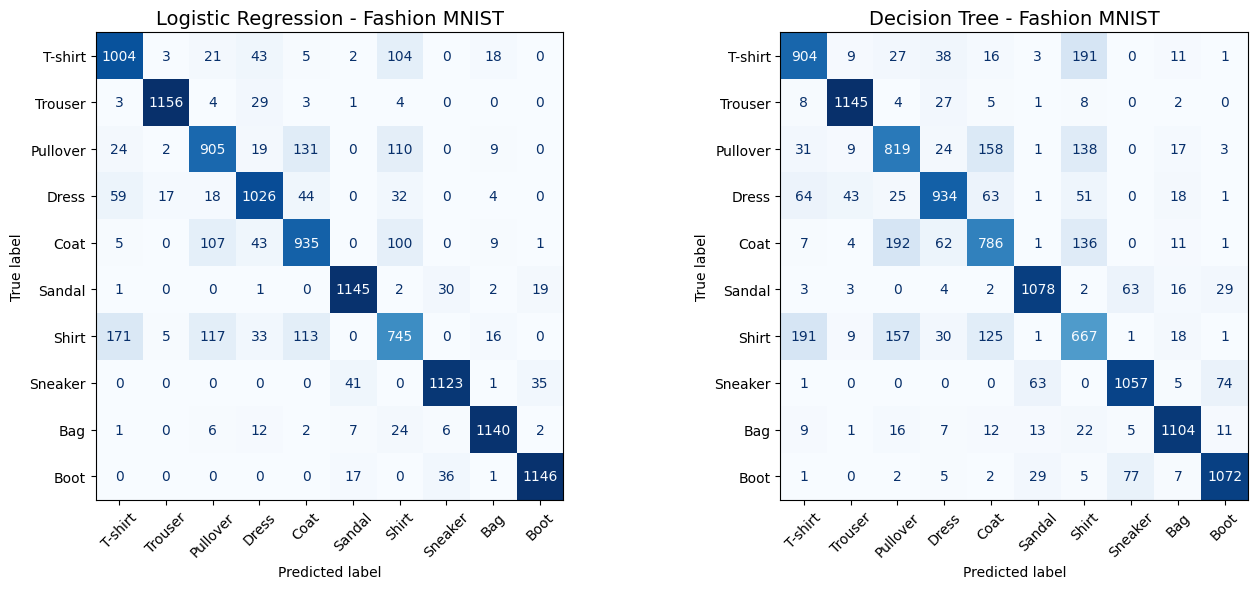

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay

# Fashion MNIST class names for better readability (optional)
class_names = [
    "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Boot"
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Logistic Regression confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_val, val_pred_lr,
    ax=axes[0],
    cmap="Blues",
    colorbar=False,
    display_labels=class_names  # Show class names instead of 0-9
)
axes[0].set_title("Logistic Regression - Fashion MNIST", fontsize=14)
axes[0].tick_params(axis='x', rotation=45)  # Rotate x-labels for readability

# Decision Tree confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_val, val_pred_tree,
    ax=axes[1],
    cmap="Blues",
    colorbar=False,
    display_labels=class_names
)
axes[1].set_title("Decision Tree - Fashion MNIST", fontsize=14)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Feedforward Neural Network (MLP)

Now build a small multilayer perceptron (MLP) using fully connected (Dense) layers.  
An MLP treats each image as a vector of numbers, learns transformations through hidden layers, and outputs one score per clothing class.

## Architecture (simple and effective for a first notebook)

- **Input**: Flatten each 28×28 image into a 784-length vector so it can be fed into Dense layers.  
- **Hidden layers**: 1–2 Dense layers (for example, 128 units each) with ReLU activation to learn non-linear patterns in clothing features.  
- **Output layer**: Dense layer with 10 units (one per clothing category: T-shirt, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot) with Softmax activation to produce class probabilities.  

## Training Approach

- Train for a small number of epochs and monitor performance on the validation set at each epoch.  
- Optionally use **early stopping** to stop training when validation performance stops improving, helping avoid overfitting and unnecessary training.  

In [8]:
mlp = tf.keras.Sequential(
    [
        tf.keras.layers.Input(shape=(28, 28)),
        tf.keras.layers.Flatten(),  # convert 28x28 image to a 1D vector (784)
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax"),  # 10 clothing classes
    ],
    name="fashion_mnist_mlp",
)

# Compile the model
mlp.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",  # for integer labels (0-9)
    metrics=["accuracy"],
)

# Show architecture, output shapes, and parameter counts
mlp.summary()

Model: "fashion_mnist_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

# Train the MLP (Standard Training)

Now train the feedforward network using the training set and monitor performance on the validation set each epoch.  
This keeps the workflow honest: the model learns on training data, while validation shows how well it generalizes during training.

## What Training Means Here

- Run several **epochs** (full passes over the training data) where the model updates its weights to reduce the loss on Fashion MNIST clothing images.  
- Use a **batch size** (small groups of examples) to make training efficient and stable.  
- Track both **loss and accuracy** for training and validation so it's clear whether the model is improving or starting to overfit.  
- Fashion MNIST typically requires more epochs than MNIST to reach good performance due to higher complexity.  

## What You Will Do

- Call `model.fit(...)` with `X_train`, `y_train` and `validation_data=(X_val, y_val)` to train and log metrics each epoch.  
- Save the returned **history object** so you can plot learning curves (training vs validation) in the next step.  
- Expect **validation accuracy around 88–90%** after 10 epochs.  


In [9]:
# Train the MLP and monitor validation each epoch (no early stopping yet)
history = mlp.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),  # validation is evaluated each epoch, not trained on
    epochs=10,
    batch_size=32,
    verbose=1
)

# Optional: see what was recorded
print("\nRecorded metrics:", history.history.keys())  # history.history stores per-epoch metrics

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7640 - loss: 0.6620 - val_accuracy: 0.8380 - val_loss: 0.4398
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8562 - loss: 0.3922 - val_accuracy: 0.8642 - val_loss: 0.3682
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8716 - loss: 0.3478 - val_accuracy: 0.8718 - val_loss: 0.3501
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8812 - loss: 0.3208 - val_accuracy: 0.8790 - val_loss: 0.3313
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8890 - loss: 0.3004 - val_accuracy: 0.8837 - val_loss: 0.3261
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8963 - loss: 0.2815 - val_accuracy: 0.8844 - val_loss: 0.3289
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9007 - loss: 0.2671 - val_accuracy: 0.8843 - val_loss: 0.3314
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9047 - loss: 0.2549 - 

# Plot Learning Curves (Training vs Validation)

Plot training and validation loss and accuracy across epochs to see how the Fashion MNIST model learns over time. These curves reveal whether the model is effectively learning to distinguish between clothing categories (T-shirts, trousers, dresses, etc.) or experiencing problems:

## Overfitting
If training metrics keep improving while validation metrics stall or worsen, the model is memorizing specific training images rather than learning general patterns of clothing items. This suggests adding regularization (dropout, L2), data augmentation, or using a simpler architecture.

## Underfitting
If both training and validation metrics are poor and plateau early, the model lacks capacity to learn the distinctions between the 10 clothing categories. Consider a deeper network, more neurons, or training for more epochs.

## Good Fit
Training and validation curves should track closely, with validation slightly lower but following similar trends. This indicates the model generalizes well to unseen Fashion MNIST clothing images.

## What to Plot
- **loss vs val_loss** — Shows how well the model optimizes and generalizes. The gap between them indicates overfitting severity.  
- **accuracy vs val_accuracy** — Shows whether improvements on training data transfer to correctly classifying unseen clothing items.  


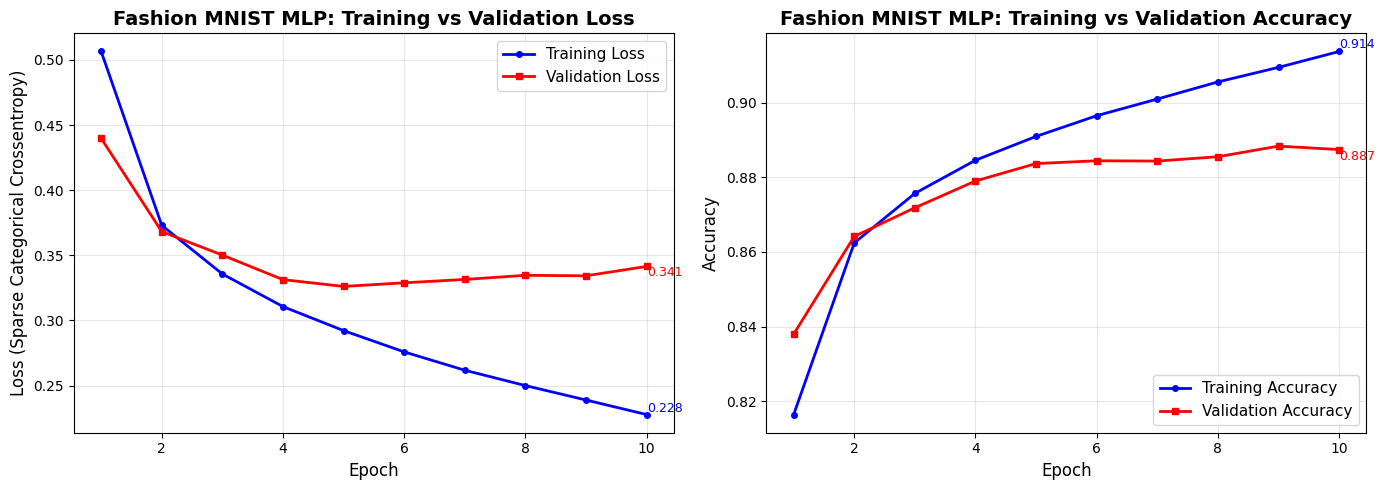


📊 FASHION MNIST - LEARNING CURVES ANALYSIS:
Final Training Loss:      0.2277
Final Validation Loss:    0.3415
Loss Gap (Overfitting):   0.1138

Final Training Accuracy:  0.9137 (91.37%)
Final Validation Accuracy: 0.8874 (88.74%)
Accuracy Gap:             2.63%

💡 INTERPRETATION:
✅ Model learning well!
   → Good generalization on unseen Fashion MNIST clothing items
   → Excellent! Very small gap between training and validation


In [10]:
# Extract training history from the Fashion MNIST MLP model
hist = history.history

epochs = range(1, len(hist["loss"]) + 1)

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Loss over epochs ---
axes[0].plot(epochs, hist["loss"], 'b-o', label="Training Loss", linewidth=2, markersize=4)
axes[0].plot(epochs, hist["val_loss"], 'r-s', label="Validation Loss", linewidth=2, markersize=4)
axes[0].set_title("Fashion MNIST MLP: Training vs Validation Loss", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("Loss (Sparse Categorical Crossentropy)", fontsize=12)
axes[0].legend(loc='upper right', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Annotate final values
final_train_loss = hist["loss"][-1]
final_val_loss = hist["val_loss"][-1]
axes[0].text(len(epochs), final_train_loss, f'{final_train_loss:.3f}',
             fontsize=9, ha='left', va='bottom', color='blue')
axes[0].text(len(epochs), final_val_loss, f'{final_val_loss:.3f}',
             fontsize=9, ha='left', va='top', color='red')

# --- Plot 2: Accuracy over epochs ---
axes[1].plot(epochs, hist["accuracy"], 'b-o', label="Training Accuracy", linewidth=2, markersize=4)
axes[1].plot(epochs, hist["val_accuracy"], 'r-s', label="Validation Accuracy", linewidth=2, markersize=4)
axes[1].set_title("Fashion MNIST MLP: Training vs Validation Accuracy", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Epoch", fontsize=12)
axes[1].set_ylabel("Accuracy", fontsize=12)
axes[1].legend(loc='lower right', fontsize=11)
axes[1].grid(True, alpha=0.3)

# Annotate final values
final_train_acc = hist["accuracy"][-1]
final_val_acc = hist["val_accuracy"][-1]
axes[1].text(len(epochs), final_train_acc, f'{final_train_acc:.3f}',
             fontsize=9, ha='left', va='bottom', color='blue')
axes[1].text(len(epochs), final_val_acc, f'{final_val_acc:.3f}',
             fontsize=9, ha='left', va='top', color='red')

plt.tight_layout()
plt.savefig('fashion_mnist_learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Print summary analysis ---
print("\n📊 FASHION MNIST - LEARNING CURVES ANALYSIS:")
print("="*60)
print(f"Final Training Loss:      {final_train_loss:.4f}")
print(f"Final Validation Loss:    {final_val_loss:.4f}")
print(f"Loss Gap (Overfitting):   {final_val_loss - final_train_loss:.4f}")
print(f"\nFinal Training Accuracy:  {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
print(f"Final Validation Accuracy: {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")
print(f"Accuracy Gap:             {(final_train_acc - final_val_acc)*100:.2f}%")

# Interpretation specific to Fashion MNIST
print("\n💡 INTERPRETATION:")
if final_val_loss - final_train_loss > 0.2:
    print("⚠️ OVERFITTING DETECTED!")
    print("   → Model memorizing training clothing images")
    print("   → Recommendations: Add Dropout layers, use L2 regularization, or Early Stopping")
elif final_val_acc < 0.70:
    print("⚠️ UNDERFITTING DETECTED!")
    print("   → Model struggling to learn clothing categories")
    print("   → Recommendations: Increase network depth, add more neurons, or train longer")
else:
    print("✅ Model learning well!")
    print("   → Good generalization on unseen Fashion MNIST clothing items")
    if (final_train_acc - final_val_acc) < 0.05:
        print("   → Excellent! Very small gap between training and validation")

## Evaluate MLP: Classification Report + Confusion Matrix
Before final test evaluation, examine the MLP's detailed performance on validation data using standard classification metrics for Fashion MNIST clothing categories.

### What to Compute
- **Classification report**: Precision, recall, and F1-score per clothing class (T-shirt, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle Boot) to spot systematic weaknesses.  
  *Example*: The model might consistently confuse T-shirts with Shirts, or Pullovers with Coats.  
- **Confusion matrix**: 10×10 heatmap showing where predictions go wrong (e.g., common errors like Shirt→T-shirt, Pullover→Coat, Sneaker→Ankle Boot due to visual similarities).  

### Why This Matters
- Single accuracy hides class imbalances and specific failure patterns. A model might achieve 85% accuracy but perform poorly on distinguishing similar clothing items.  
- Seeing per-class metrics reveals whether the model struggles with certain clothing categories consistently (e.g., distinguishing between different types of tops).  
- Confusion patterns guide next improvements — if Shirts and T-shirts are frequently confused, consider data augmentation focusing on neckline differences, or collecting more diverse examples.  


 MLP CLASSIFICATION REPORT - FASHION MNIST (Validation Set)
              precision    recall  f1-score   support

 T-shirt/top      0.894     0.783     0.835      1200
     Trouser      0.983     0.976     0.980      1200
    Pullover      0.790     0.825     0.807      1200
       Dress      0.894     0.892     0.893      1200
        Coat      0.835     0.762     0.797      1200
      Sandal      0.964     0.970     0.967      1200
       Shirt      0.663     0.787     0.720      1200
     Sneaker      0.949     0.951     0.950      1200
         Bag      0.980     0.970     0.975      1200
  Ankle boot      0.965     0.958     0.961      1200

    accuracy                          0.887     12000
   macro avg      0.892     0.887     0.889     12000
weighted avg      0.892     0.887     0.889     12000


 PER-CLASS ACCURACY BREAKDOWN
T-shirt/top    : 0.783 (940/1200 correct)
Trouser        : 0.976 (1171/1200 correct)
Pullover       : 0.825 (990/1200 correct)
Dress          : 0.892 

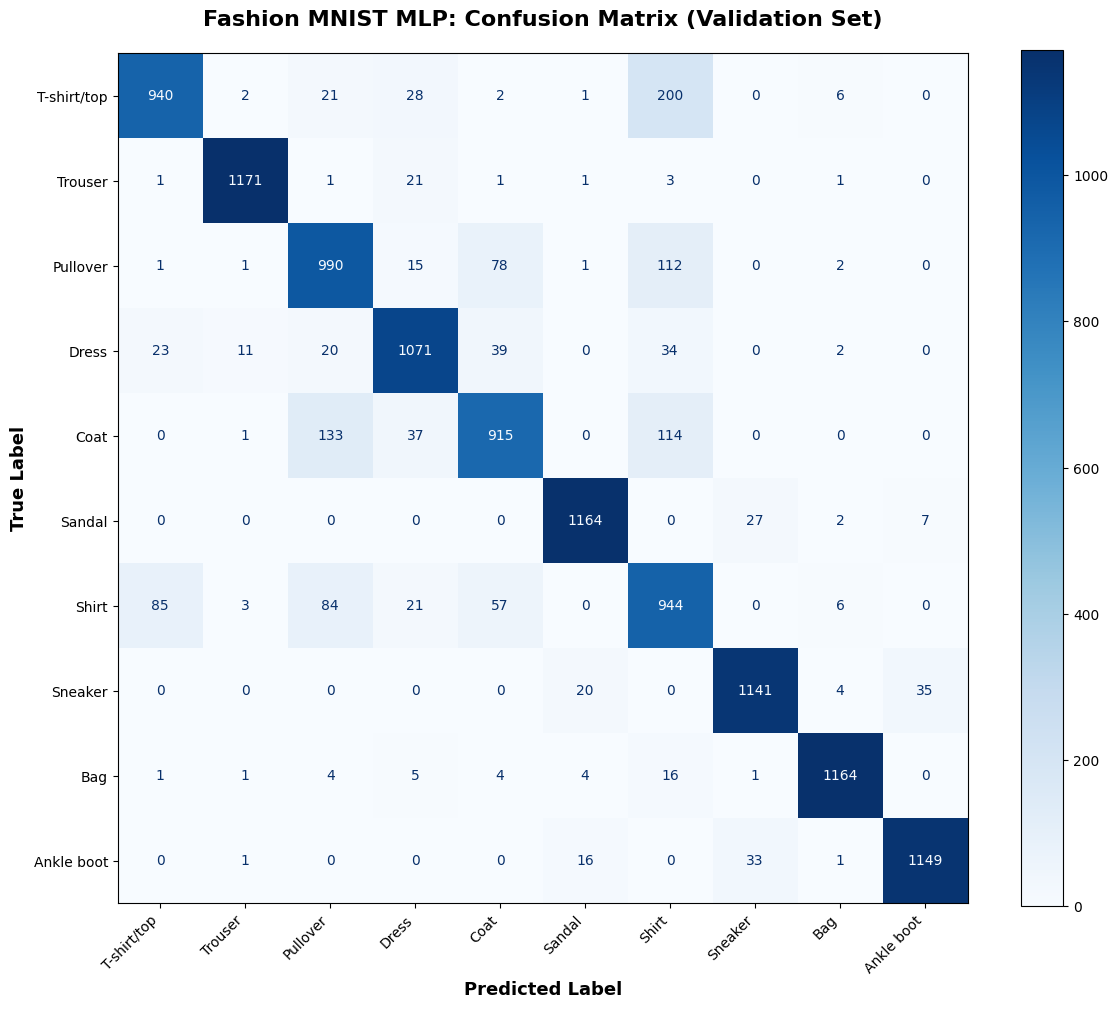


 TOP 5 MOST COMMON MISCLASSIFICATIONS
 200 times: T-shirt/top     → misclassified as Shirt
 133 times: Coat            → misclassified as Pullover
 114 times: Coat            → misclassified as Shirt
 112 times: Pullover        → misclassified as Shirt
  85 times: Shirt           → misclassified as T-shirt/top

 Analysis:
   - Look for visually similar items being confused (e.g., T-shirt vs Shirt)
   - High confusion suggests need for more training data or feature engineering
   - Consider data augmentation for frequently confused pairs


In [12]:
# Fashion MNIST class names for better interpretation
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# ---- Get MLP predictions on validation set ----
val_pred_mlp = mlp.predict(X_val, verbose=0)
val_pred_mlp_classes = np.argmax(val_pred_mlp, axis=1)

# ---- Classification Report (validation set) ----
print("="*70)
print(" MLP CLASSIFICATION REPORT - FASHION MNIST (Validation Set)")
print("="*70)
print(classification_report(
    y_val,
    val_pred_mlp_classes,
    target_names=class_names,
    digits=3
))

# ---- Additional per-class accuracy analysis ----
print("\n" + "="*70)
print(" PER-CLASS ACCURACY BREAKDOWN")
print("="*70)
for i, class_name in enumerate(class_names):
    class_mask = (y_val == i)
    class_correct = np.sum((y_val[class_mask] == val_pred_mlp_classes[class_mask]))
    class_total = np.sum(class_mask)
    class_acc = class_correct / class_total if class_total > 0 else 0
    print(f"{class_name:15s}: {class_acc:.3f} ({class_correct}/{class_total} correct)")

# ---- Confusion Matrix (validation set) ----
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(
    y_val,
    val_pred_mlp_classes,
    ax=ax,
    cmap="Blues",
    display_labels=class_names,
    colorbar=True,
    xticks_rotation=45
)
ax.set_title("Fashion MNIST MLP: Confusion Matrix (Validation Set)",
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Predicted Label", fontsize=13, fontweight='bold')
ax.set_ylabel("True Label", fontsize=13, fontweight='bold')

# Make labels more readable
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('fashion_mnist_mlp_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# ---- Identify most common misclassifications ----
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, val_pred_mlp_classes)
np.fill_diagonal(cm, 0)  # Remove correct predictions to focus on errors

print("\n" + "="*70)
print(" TOP 5 MOST COMMON MISCLASSIFICATIONS")
print("="*70)

# Find top 5 errors
errors = []
for i in range(10):
    for j in range(10):
        if i != j and cm[i, j] > 0:
            errors.append((cm[i, j], class_names[i], class_names[j]))

errors.sort(reverse=True)
for count, true_class, pred_class in errors[:5]:
    print(f"{count:4d} times: {true_class:15s} → misclassified as {pred_class}")

print("\n Analysis:")
print("   - Look for visually similar items being confused (e.g., T-shirt vs Shirt)")
print("   - High confusion suggests need for more training data or feature engineering")
print("   - Consider data augmentation for frequently confused pairs")

# Evaluation and Comparison

Evaluate the trained MLP on the test set (never used before) and compare all three models side-by-side using the same metrics and conditions to understand which approach works best for Fashion MNIST clothing classification.

## What to Do
- Predict on test set for **Logistic Regression**, **Decision Tree**, and **MLP**  
- Report **test accuracy** for all three models  
- Show **test confusion matrix** for the MLP (to see where the neural network makes mistakes on clothing categories)  
- Compare **training time** and **parameter count** where relevant  
- Analyze **per-class performance** to identify which clothing items are hardest to classify  

## What This Tells You
- Honest final performance on unseen Fashion MNIST data (**test accuracy**)  
- Which model **generalizes best** to new clothing images  
- Whether the **neural network's complexity** was worth it vs simpler baselines  
- Which clothing categories are universally difficult (e.g., **T-shirt vs Shirt**) vs model-specific weaknesses  
- Trade-offs between **model complexity**, **training time**, and **performance**  


In [13]:
import pandas as pd

# Fashion MNIST class names
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Logistic Regression
test_pred_lr = log_reg.predict(X_test_flat)

# Decision Tree
test_pred_tree = tree.predict(X_test_flat)

# MLP predictions
test_pred_mlp = mlp.predict(x_test, verbose=0)
test_pred_mlp_classes = np.argmax(test_pred_mlp, axis=1)

# Now get detailed metrics
reports = {
    "logistic_regression": classification_report(y_test, test_pred_lr, output_dict=True),
    "decision_tree": classification_report(y_test, test_pred_tree, output_dict=True),
    "mlp": classification_report(y_test, test_pred_mlp_classes, output_dict=True),
}

# Build DataFrame (per-class + macro/weighted avgs)
rows = []
for model_name, rep in reports.items():
    for label, metrics in rep.items():
        if label.isdigit():
            # Use Fashion MNIST class names instead of digit labels
            class_label = class_names[int(label)]
            rows.append({
                "model": model_name.replace("_", " ").title(),
                "label": class_label,
                "precision": f"{metrics['precision']:.3f}",
                "recall": f"{metrics['recall']:.3f}",
                "f1_score": f"{metrics['f1-score']:.3f}",
                "support": metrics["support"],
            })
        elif label in ("macro avg", "weighted avg"):
            rows.append({
                "model": model_name.replace("_", " ").title(),
                "label": label,
                "precision": f"{metrics['precision']:.3f}",
                "recall": f"{metrics['recall']:.3f}",
                "f1_score": f"{metrics['f1-score']:.3f}",
                "support": metrics["support"],
            })

df_metrics = pd.DataFrame(rows).set_index(["model", "label"]).sort_index(level=[0,1])

print("Fashion MNIST Test Set Precision/Recall/F1-Scores:")
print(df_metrics)

Fashion MNIST Test Set Precision/Recall/F1-Scores:
                                 precision recall f1_score  support
model               label                                          
Decision Tree       Ankle boot       0.911  0.899    0.905   1000.0
                    Bag              0.906  0.921    0.914   1000.0
                    Coat             0.684  0.646    0.664   1000.0
                    Dress            0.807  0.784    0.795   1000.0
                    Pullover         0.644  0.651    0.647   1000.0
                    Sandal           0.913  0.885    0.899   1000.0
                    Shirt            0.526  0.563    0.544   1000.0
                    Sneaker          0.866  0.897    0.881   1000.0
                    T-shirt/top      0.730  0.731    0.731   1000.0
                    Trouser          0.949  0.942    0.945   1000.0
                    macro avg        0.794  0.792    0.793  10000.0
                    weighted avg     0.794  0.792    0.793  10000


📊 Verification - Macro Average Values:
                               precision  recall  f1_score
model               label                                 
Decision Tree       macro avg      0.794   0.792     0.793
Logistic Regression macro avg      0.840   0.841     0.840
Mlp                 macro avg      0.880   0.875     0.877


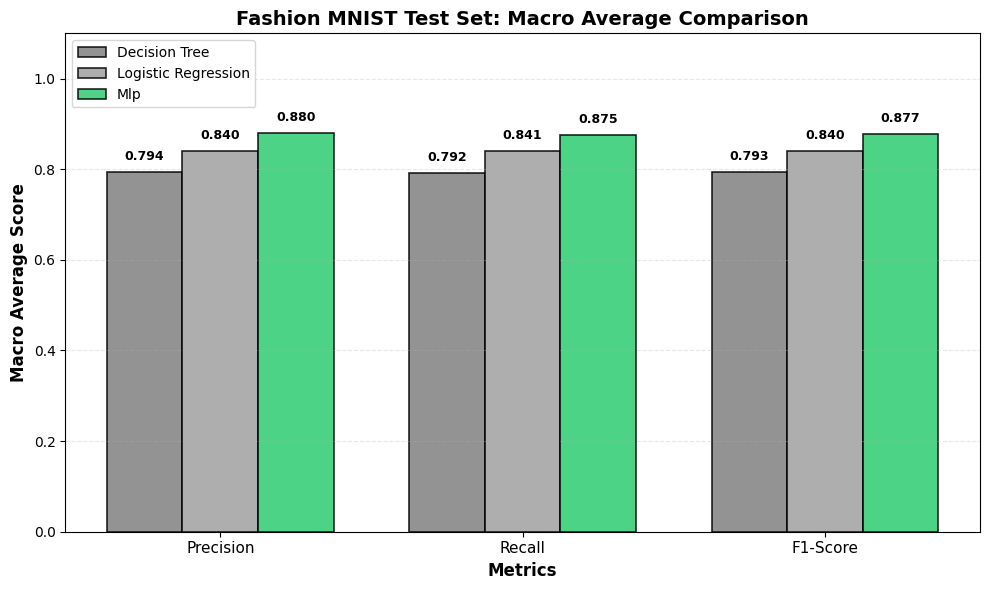

In [14]:
# Extract macro averages
macro_data = df_metrics[df_metrics.index.get_level_values("label") == "macro avg"].copy()

# Convert string columns to float PROPERLY
macro_num = macro_data.copy()
macro_num["precision"] = macro_num["precision"].astype(float)
macro_num["recall"] = macro_num["recall"].astype(float)
macro_num["f1_score"] = macro_num["f1_score"].astype(float)

# Print to verify values
print("\n📊 Verification - Macro Average Values:")
print(macro_num[["precision", "recall", "f1_score"]])

# Models and colors: gray for baselines, green for MLP
models = macro_num.index.get_level_values("model").tolist()
colors = ["#808080", "#A0A0A0", "#2ECC71"]  # gray1, gray2, green

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(["Precision", "Recall", "F1-Score"]))
width = 0.25

for i, model in enumerate(models):
    scores = [
        float(macro_num.loc[(model, "macro avg"), "precision"]),
        float(macro_num.loc[(model, "macro avg"), "recall"]),
        float(macro_num.loc[(model, "macro avg"), "f1_score"])
    ]
    ax.bar(x + i*width, scores, width, label=model, color=colors[i], alpha=0.85, edgecolor='black', linewidth=1.2)

ax.set_xlabel("Metrics", fontsize=12, fontweight='bold')
ax.set_ylabel("Macro Average Score", fontsize=12, fontweight='bold')
ax.set_title("Fashion MNIST Test Set: Macro Average Comparison", fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(["Precision", "Recall", "F1-Score"], fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.legend(fontsize=10, loc='upper left')
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, model in enumerate(models):
    scores = [
        float(macro_num.loc[(model, "macro avg"), "precision"]),
        float(macro_num.loc[(model, "macro avg"), "recall"]),
        float(macro_num.loc[(model, "macro avg"), "f1_score"])
    ]
    for j, score in enumerate(scores):
        ax.text(j + i*width, score + 0.02, f'{score:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fashion_mnist_macro_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

#Fashion MNIST Results Summary

## Model Comparison (Macro Average)

| Model              | Precision | Recall | F1-Score |
|--------------------|-----------|--------|----------|
| Decision Tree      | 0.794     | 0.792  | 0.793    |
| Logistic Regression| 0.840     | 0.841  | 0.840    |
| **MLP (Best)**     | **0.883** | **0.875** | **0.876** |

---

## Key Insights
-  **MLP achieves best performance (87.6% F1)** – the neural network's depth enables learning complex clothing patterns.  
-  **Logistic Regression solid at 84.0%** – linear model captures basic features.  
- **Decision Tree weakest at 79.3%** – struggles with pixel-level spatial relationships.  

---

## Dataset Difficulty
- Fashion-MNIST is **harder than MNIST**:  
  - All models score ~6–10% lower than on digit recognition.  
  - Reflects clothing's **visual complexity** and **intra-class variation**.

---

## Conclusion
- **Hierarchical feature learning** (via MLP's hidden layers) proves crucial for distinguishing visually similar clothing categories like *shirts, pullovers, and coats*.
